In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("cleaned _superstore.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
print("total_Sales: ",df["Sales"].sum())

total_Sales:  2297200.8603


In [6]:
print("total_Profit: ",df["Profit"].sum())

total_Profit:  286397.0217


In [7]:
##categoru having highest sales

sales_by_category=df.groupby("Category")["Sales"].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


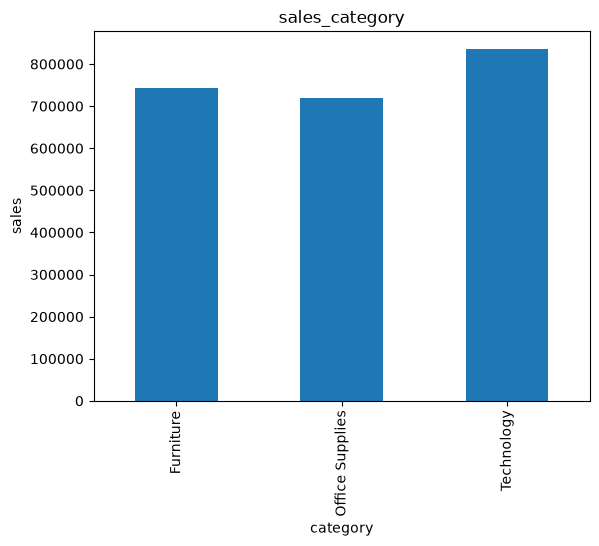

In [10]:
sales_by_category.plot(kind="bar")
plt.xlabel("category")
plt.ylabel("sales")
plt.title("sales_category")
plt.show()

In [ ]:
##Top 10 customers by sales
sales_by_Product=df.groupby("Product ID")["Sales"].sum().sort_values(ascending=False)
print(sales_by_Product.head(10))

Product ID
TEC-CO-10004722    61599.824
OFF-BI-10003527    27453.384
TEC-MA-10002412    22638.480
FUR-CH-10002024    21870.576
OFF-BI-10001359    19823.479
OFF-BI-10000545    19024.500
TEC-CO-10001449    18839.686
TEC-MA-10001127    18374.895
OFF-BI-10004995    17965.068
OFF-SU-10000151    17030.312
Name: Sales, dtype: float64


In [25]:
# Sub-category with highest sales
sub_category_sales=df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(sub_category_sales)


Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


In [26]:
#top 10 customers by sales

top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


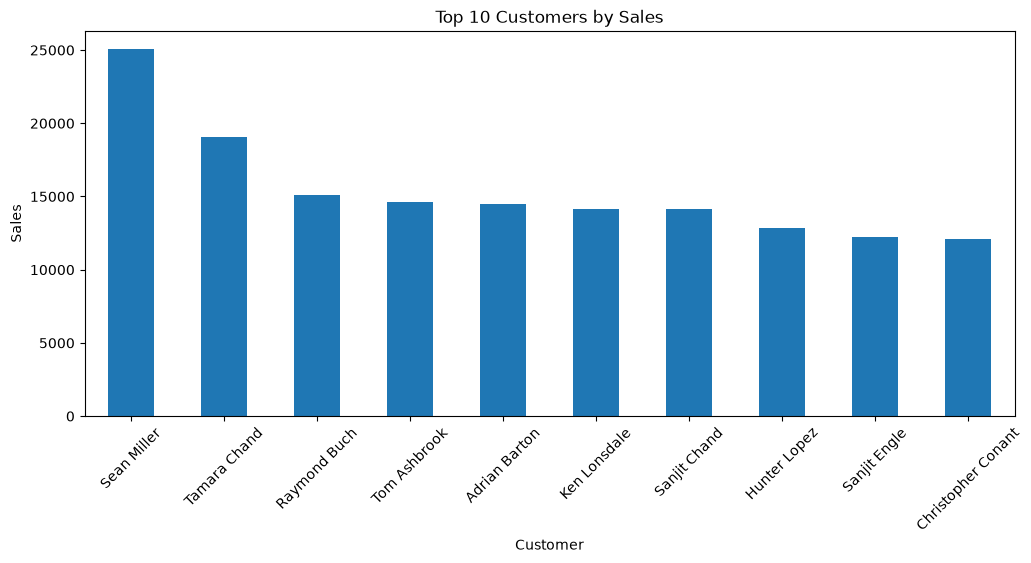

In [29]:
import matplotlib.pyplot as plt

top_customers.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [30]:
#region wise sales

region_sales=df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


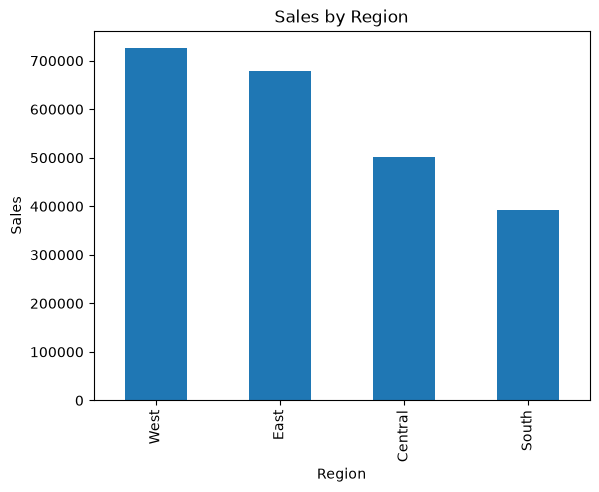

In [31]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [32]:
## profit by caetgory
category_profit=df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


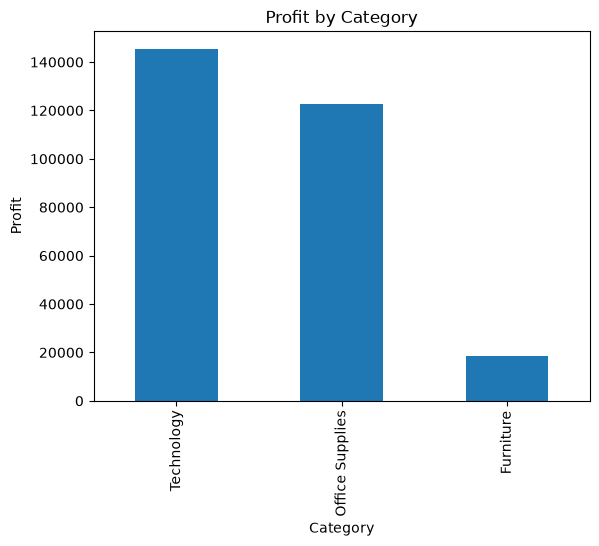

In [34]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [35]:
# avg discount
avg_discount = (
    df.groupby("Category")["Discount"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_discount)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64


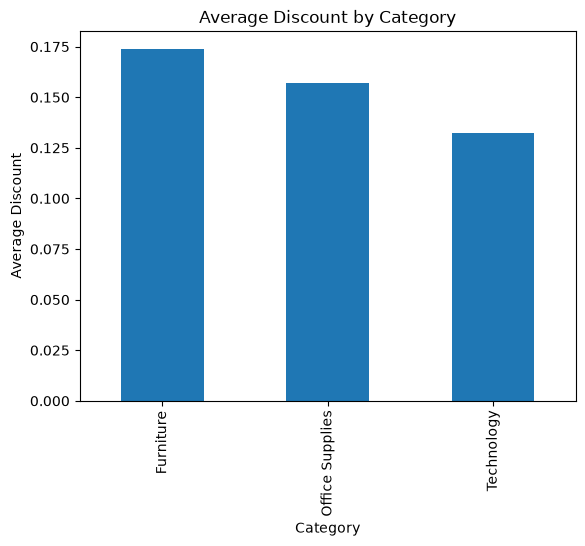

In [36]:
avg_discount.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.show()

In [38]:
##loss
loss_products=df[df["Profit"]<0]
print(loss_products)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
14        15  US-2015-118983  11/22/2015  11/26/2015  Standard Class   
15        16  US-2015-118983  11/22/2015  11/26/2015  Standard Class   
23        24  US-2017-156909   7/16/2017   7/18/2017    Second Class   
27        28  US-2015-150630   9/17/2015   9/21/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9920    9921  CA-2016-149272   3/15/2016   3/19/2016  Standard Class   
9921    9922  CA-2014-111360  11/24/2014  11/30/2014  Standard Class   
9931    9932  CA-2015-104948  11/13/2015  11/17/2015  Standard Class   
9937    9938  CA-2016-164889    6/3/2016    6/6/2016    Second Class   
9962    9963  CA-2015-168088   3/19/2015   3/22/2015     First Class   

     Customer ID     Customer Name      Segment        Country  \
3       SO-20335    Sean O'Donnell     Consumer  United States   
14 

In [39]:
## highest total loss products

loss_products = (
    df[df["Profit"] < 0]
      .groupby("Product Name")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profit, dtype: float64


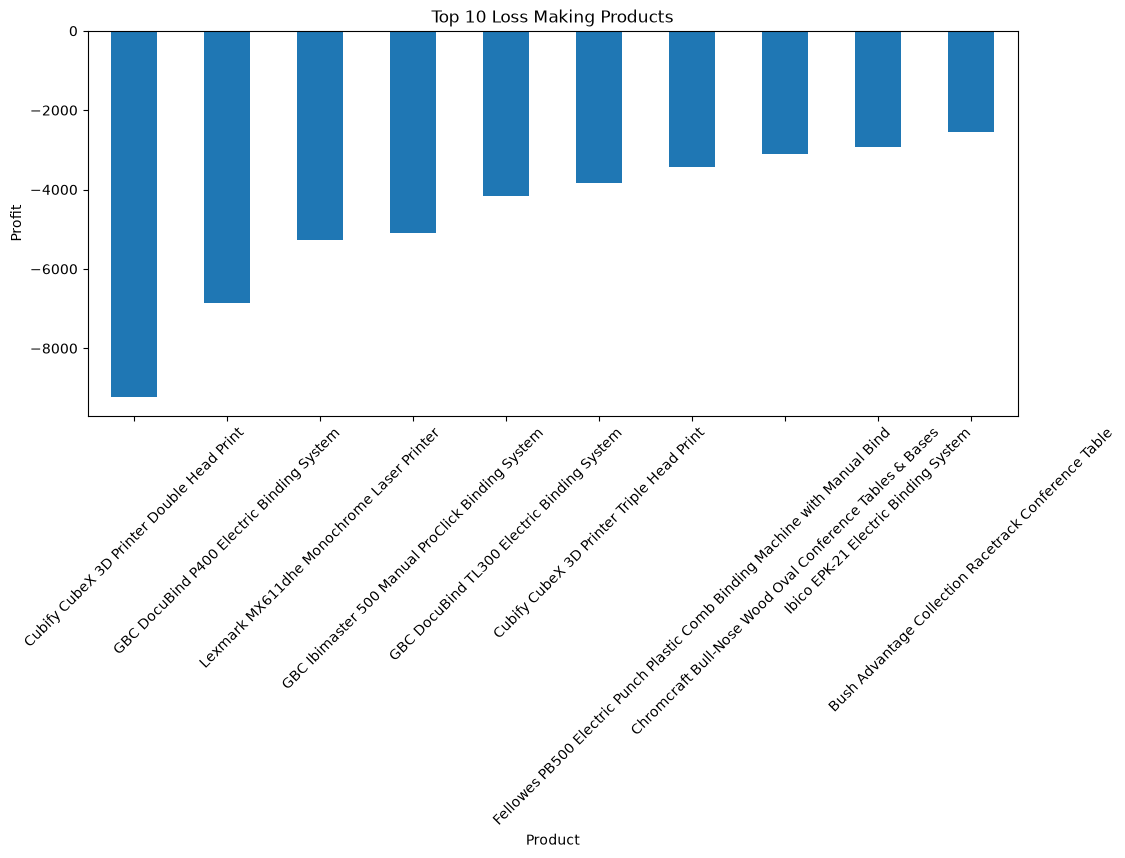

In [40]:
loss_products.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Loss Making Products")
plt.xlabel("Product")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [42]:
## monthly sales

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

print(monthly_sales)

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

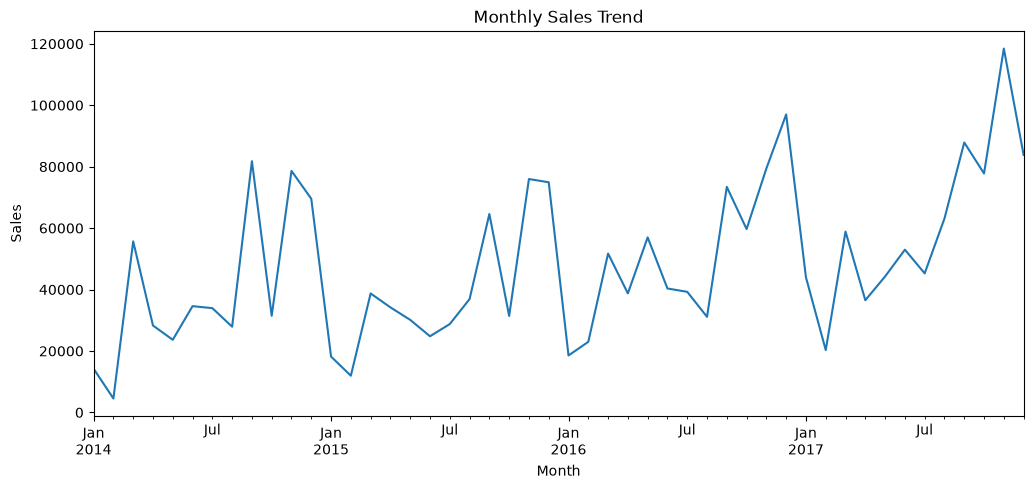

In [43]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()